# Coffea-Casa Benchmark Example 1

In [1]:
import numpy as np
%matplotlib inline
import hist
import coffea.processor as processor
import awkward as ak
from coffea.nanoevents import schemas
from coffea.util import split_fileset, hash_fileset, load, save

In [2]:
# This program plots an event-level variable (in this case, MET, but switching it is as easy as a dict-key change). It also demonstrates an easy use of the book-keeping cutflow tool, to keep track of the number of events processed.

# The processor class bundles our data analysis together while giving us some helpful tools.  It also leaves looping and chunks to the framework instead of us.
class Processor(processor.ProcessorABC):
    def __init__(self):
        # Bins and categories for the histogram are defined here. For format, see https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Hist.html && https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Bin.html
        dataset_axis = hist.axis.StrCategory(name="dataset", label="", categories=[], growth=True)
        MET_axis = hist.axis.Regular(name="MET", label="MET [GeV]", bins=50, start=0, stop=100)
        
        # The accumulator keeps our data chunks together for histogramming. It also gives us cutflow, which can be used to keep track of data.
        self.output = processor.dict_accumulator({
            'MET': hist.Hist(dataset_axis, MET_axis),
            'cutflow': processor.defaultdict_accumulator(int)
        })
    
    def process(self, events):
        # This is where we do our actual analysis. The dataset has columns similar to the TTree's; events.columns can tell you them, or events.[object].columns for deeper depth.
        dataset = events.metadata["dataset"]
        MET = events.MET.pt
        
        # We can define a new key for cutflow (in this case 'all events'). Then we can put values into it. We need += because it's per-chunk (demonstrated below)
        self.output['cutflow']['all events'] += len(MET)
        self.output['cutflow']['number of chunks'] += 1
        
        # This fills our histogram once our data is collected. The hist key ('MET=') will be defined in the bin in __init__.
        self.output['MET'].fill(dataset=dataset, MET=MET)
        return self.output
    
    def postprocess(self, accumulator):
        pass

In [3]:
# from dask.distributed import Client

# client = Client("tls://localhost:8786")

In [4]:
fileset = {'SingleMu_0':
           {"files":  {
             # { "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/01919AD6-5EA0-EB47-B21D-89121FC0C8C6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/055FA10B-C4F0-BD43-AB89-DDBA00814DF6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/4DD47A6B-2C21-F142-9929-A351DAFD1473.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/567E763E-F1EF-3745-A1DD-3214C8048EA6.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/715DB643-831D-6D47-8540-63F937CF48F4.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/86F1B4C4-76B0-F949-8DB4-90346A679401.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/953EFAF4-0F31-754C-9601-246C549A2E25.root": "Events",
                # broken link
                "root://eeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/C6E8BB7F-7F54-0C4C-9EDF-479C7DBB12E4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CB90AA65-868A-F548-A291-3837A3113162.root": "Events",
                }
           },
           'SingleMu_1':
           {"files":  {
             # { "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/07D89838-5D7E-CC4E-BD6B-6CA67597D89A.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CF50DAD4-FDE3-D747-A24B-7F7D0B935DE0.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/D5C5C4B1-6A02-5D43-B0C1-16BB2E6145B2.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/F78228AB-4C38-4141-84FE-03928A8D0893.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0AA3D645-4912-364C-B61D-B41EDD892DE4.root": "Events",
             #    "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0F41DD13-E950-5446-A1F1-25DA7AFCB2F5.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/2CCE1139-F301-C341-AE1E-4D27AF294018.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/300C603C-F1DD-4A40-B4DD-F4E0B239A460.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/39251543-EE21-9C4C-80D5-5D9178F55C71.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/3BD29D89-9C4A-E743-8616-C6806281BF12.root": "Events",
            }
           }
          }

# executor = processor.DaskExecutor(client=client)
executor = processor.FuturesExecutor()

run = processor.Runner(executor=executor,
                        schema=schemas.NanoAODSchema,
                        savemetrics=True
                      )

import pprint

chunks_1 = split_fileset(fileset, strategy="by_dataset")
pprint.pprint(chunks_1)
print()
print("--------------------------------------------------------------------------------------")
print()
chunks_2 = split_fileset(fileset, strategy="by_dataset", percentage=20)
pprint.pprint(chunks_2)
print()
print("--------------------------------------------------------------------------------------")
print()
chunks_3 = split_fileset(fileset, percentage=20)
pprint.pprint(chunks_3)
print()
print("--------------------------------------------------------------------------------------")
print()
chunks_4 = split_fileset(fileset, strategy="by_dataset", datasets=["SingleMu_1"])
pprint.pprint(chunks_4)

[{'SingleMu_0': {'files': {'root://eeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asympt

In [5]:
result = None

In [6]:
# 2 filesets (SingleMu_0, SingleMu_1), broken link in SingleMu_0 subset
for chunk in chunks_1:
    try:
        output, metrics = run(chunk, processor_instance=Processor())
        if result is None:
            result = output
        else:
            result += output
    except BaseException as e:
        print(f"Error: {e}")
        continue

Output()

/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py:1166: UserWarning: Performed attempt 1 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1180, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1164, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1234, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Error: Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7fc707a99520>> request: [FATAL] Invalid address


Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcde4f6150>, errorbar=None, legend_artist=None)]

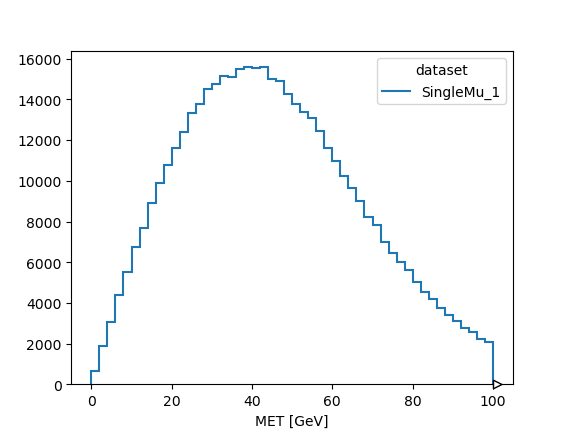

In [7]:
# Generates a 1D histogram from the data output to the 'MET' key. fill_opts are optional, to fill the graph (default is a line).
result['MET'].plot1d()

In [9]:
# Easy way to print all cutflow dict values. Can just do print(output['cutflow']["KEY_NAME"]) for one.
for key, value in result['cutflow'].items():
    print(key, value)

all events 482000
number of chunks 6


In [10]:
# strategy="by_dataset", percentage=20: each dataset is splitted separately by 100/20=5 chunks, * by 2 datasets (SingleMu_0, SingleMu_1) -> 10 chunks
result_2 = None
for chunk in chunks_2:
    try:
        output, metrics = run(chunk, processor_instance=Processor())
        if result_2 is None:
            result_2 = output
        else:
            result_2 += output
    except BaseException as e:
        print(f"Error: {e}")
        continue

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1180, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1164, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1234, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Error: Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7f149d752ea0>> request: [FATAL] Invalid address


Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcde4e2ea0>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcdedafb30>, errorbar=None, legend_artist=None)]

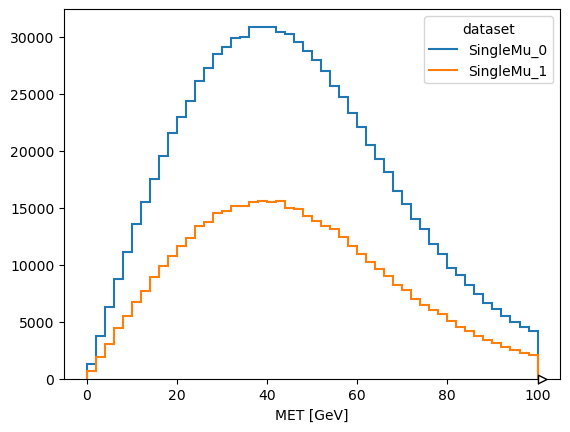

In [11]:
result_2['MET'].plot1d()

In [12]:
for key, value in result_2['cutflow'].items():
    print(key, value)

all events 1439000
number of chunks 17


In [13]:
# percentage=20, 5 mixed chunks: 1st chunk is 20% of SingleMu_0 + 20% of SingleMu_1 ...
result_3 = None
for chunk in chunks_3:
    try:
        output, metrics = run(chunk, processor_instance=Processor())
        if result_3 is None:
            result_3 = output
        else:
            result_3 += output
    except BaseException as e:
        print(f"Error: {e}")
        continue

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1180, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1164, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1234, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Error: Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7f1da6d6f8c0>> request: [FATAL] Invalid address


Output()

Output()

Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcde2aa210>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcde44bec0>, errorbar=None, legend_artist=None)]

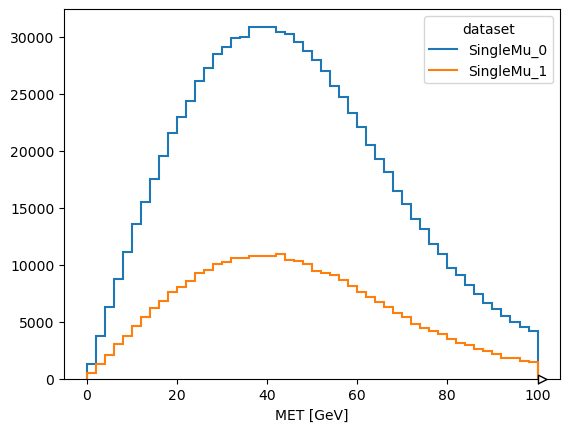

In [14]:
result_3['MET'].plot1d()

In [16]:
for key, value in result_3['cutflow'].items():
    print(key, value)

all events 1292000
number of chunks 16


In [17]:
# strategy="by_dataset" & datasets=["SingleMu_1"]: only SingleMu_1 as 1 chunk
result_4 = None
for chunk in chunks_4:
    try:
        output, metrics = run(chunk, processor_instance=Processor())
        if result_4 is None:
            result_4 = output
        else:
            result_4 += output
    except BaseException as e:
        print(f"Error: {e}")
        continue

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fbcde2aa540>, errorbar=None, legend_artist=None)]

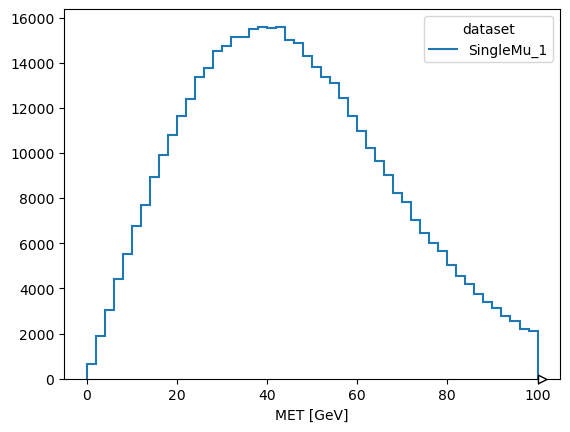

In [18]:
result_4['MET'].plot1d()

In [19]:
for key, value in result_4['cutflow'].items():
    print(key, value)

all events 482000
number of chunks 6
